# Model Recovery Analysis

This notebook analyzes the results of the model recovery experiment, where different models are used to generate synthetic data and then all models are fit to that data to see which model best recovers the true generating model.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from popy.config import PROJECT_PATH_LOCAL

/home/uzsombi/.config/matplotlib is not a writable directory
Matplotlib created a temporary cache directory at /tmp/matplotlib-j2e6lrhv because there was an issue with the default path (/home/uzsombi/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


## Load Results

In [7]:
# Load the model recovery results
results_path = os.path.join(PROJECT_PATH_LOCAL, "notebooks", "behav_modeling", "results", "recovery", "model_recovery_10k.csv")
df = pd.read_csv(results_path)

# sort by model_true, iteration, model_fitted
df = df.sort_values(by=['model_true', 'iteration', 'model_fitted']).reset_index(drop=True)

# remove when beta < 5 or epsilon > .4
#df = df[(df["beta"] < 20) & (df["beta"] > 1)]

print(f"Loaded {len(df)} simulations")
df

Loaded 900 simulations


,model_true,model_fitted,iteration,alpha,beta,stickiness_bias,alpha_recovered,beta_recovered,stickiness_bias_recovered,LPT_best,V0,V0_recovered
0,Foraging,Foraging,0,0.429288,6.279654,NaN,0.358653,7.512074,NaN,0.511604,0.321244,0.352760
1,Foraging,Inferential RL - stickiness,0,0.429288,6.279654,NaN,0.730035,1.888728,1.576635,0.495589,0.321244,NaN
2,Foraging,Standard RL - stickiness,0,0.429288,6.279654,NaN,0.389118,2.785746,1.158414,0.464353,0.321244,NaN
3,Foraging,Foraging,1,0.350213,6.370626,NaN,0.321578,7.423149,NaN,0.686078,0.050051,0.108900
4,Foraging,Inferential RL - stickiness,1,0.350213,6.370626,NaN,0.635777,1.855338,2.821763,0.653605,0.050051,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
895,Standard RL - stickiness,Inferential RL - stickiness,98,0.371142,1.897931,1.071304,0.429187,1.204091,1.410533,0.435287,NaN,NaN
896,Standard RL - stickiness,Standard RL - stickiness,98,0.371142,1.897931,1.071304,0.675445,0.050000,1.371240,0.420998,NaN,NaN
897,Standard RL - stickiness,Foraging,99,0.213232,6.854237,0.076596,0.219369,6.396040,NaN,0.506596,NaN,0.263817
898,Standard RL - stickiness,Inferential RL - stickiness,99,0.213232,6.854237,0.076596,0.066522,8.206241,0.584239,0.543706,NaN,NaN


In [3]:
# remove all entries of WSLS
df = df[~df["model_true"].str.contains("WSLS")].reset_index(drop=True)
df = df[~df["model_fitted"].str.contains("WSLS")].reset_index(drop=True)

df

,model_true,model_fitted,iteration,alpha,beta,stickiness_bias,alpha_recovered,beta_recovered,stickiness_bias_recovered,LPT_best,V0,V0_recovered
0,Foraging,Foraging,0,0.429288,6.279654,NaN,0.358653,7.512074,NaN,0.511604,0.321244,0.352760
1,Foraging,Inferential RL - stickiness,0,0.429288,6.279654,NaN,0.730035,1.888728,1.576635,0.495589,0.321244,NaN
2,Foraging,Standard RL - stickiness,0,0.429288,6.279654,NaN,0.389118,2.785746,1.158414,0.464353,0.321244,NaN
3,Foraging,Foraging,1,0.350213,6.370626,NaN,0.321578,7.423149,NaN,0.686078,0.050051,0.108900
4,Foraging,Inferential RL - stickiness,1,0.350213,6.370626,NaN,0.635777,1.855338,2.821763,0.653605,0.050051,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
895,Standard RL - stickiness,Inferential RL - stickiness,98,0.371142,1.897931,1.071304,0.429187,1.204091,1.410533,0.435287,NaN,NaN
896,Standard RL - stickiness,Standard RL - stickiness,98,0.371142,1.897931,1.071304,0.675445,0.050000,1.371240,0.420998,NaN,NaN
897,Standard RL - stickiness,Foraging,99,0.213232,6.854237,0.076596,0.219369,6.396040,NaN,0.506596,NaN,0.263817
898,Standard RL - stickiness,Inferential RL - stickiness,99,0.213232,6.854237,0.076596,0.066522,8.206241,0.584239,0.543706,NaN,NaN


## Diagonal-only: Parameter recovery + LPT by model

For model recovery runs, the *diagonal* (`model_true == model_fitted`) corresponds to **parameter recovery** (fit the same model that generated the data).
Below we (1) plot true vs recovered parameters on the diagonal only, and (2) plot the LPT distribution per model on the diagonal only.

Diagonal rows (parameter recovery): 300


Diagonal rows (parameter recovery): 300


,model_true,model_fitted,iteration,alpha,beta,stickiness_bias,alpha_recovered,beta_recovered,stickiness_bias_recovered,LPT_best,V0,V0_recovered
0,Foraging,Foraging,0,0.429288,6.279654,NaN,0.358653,7.512074,NaN,0.511604,0.321244,0.352760
3,Foraging,Foraging,1,0.350213,6.370626,NaN,0.321578,7.423149,NaN,0.686078,0.050051,0.108900
6,Foraging,Foraging,2,0.361597,3.988790,NaN,0.342569,4.155493,NaN,0.454579,0.245895,0.240599
9,Foraging,Foraging,3,0.430479,6.157539,NaN,0.414226,6.392551,NaN,0.593630,0.180907,0.180958
12,Foraging,Foraging,4,0.680218,3.961880,NaN,0.788190,3.395810,NaN,0.430696,0.487708,0.455558


Diagonal rows (parameter recovery): 300


,model_true,model_fitted,iteration,alpha,beta,stickiness_bias,alpha_recovered,beta_recovered,stickiness_bias_recovered,LPT_best,V0,V0_recovered
0,Foraging,Foraging,0,0.429288,6.279654,NaN,0.358653,7.512074,NaN,0.511604,0.321244,0.352760
3,Foraging,Foraging,1,0.350213,6.370626,NaN,0.321578,7.423149,NaN,0.686078,0.050051,0.108900
6,Foraging,Foraging,2,0.361597,3.988790,NaN,0.342569,4.155493,NaN,0.454579,0.245895,0.240599
9,Foraging,Foraging,3,0.430479,6.157539,NaN,0.414226,6.392551,NaN,0.593630,0.180907,0.180958
12,Foraging,Foraging,4,0.680218,3.961880,NaN,0.788190,3.395810,NaN,0.430696,0.487708,0.455558


Detected parameters: ['V0', 'alpha', 'beta', 'stickiness_bias']
Models (diagonal): ['Foraging', 'Inferential RL - stickiness', 'Standard RL - stickiness']
Foraging - alpha: r=0.89, p=1.5546322695324452e-34
Foraging - beta: r=0.70, p=7.333698726172779e-16
Foraging - V0: r=0.95, p=9.299289184573168e-52


Diagonal rows (parameter recovery): 300


,model_true,model_fitted,iteration,alpha,beta,stickiness_bias,alpha_recovered,beta_recovered,stickiness_bias_recovered,LPT_best,V0,V0_recovered
0,Foraging,Foraging,0,0.429288,6.279654,NaN,0.358653,7.512074,NaN,0.511604,0.321244,0.352760
3,Foraging,Foraging,1,0.350213,6.370626,NaN,0.321578,7.423149,NaN,0.686078,0.050051,0.108900
6,Foraging,Foraging,2,0.361597,3.988790,NaN,0.342569,4.155493,NaN,0.454579,0.245895,0.240599
9,Foraging,Foraging,3,0.430479,6.157539,NaN,0.414226,6.392551,NaN,0.593630,0.180907,0.180958
12,Foraging,Foraging,4,0.680218,3.961880,NaN,0.788190,3.395810,NaN,0.430696,0.487708,0.455558


Detected parameters: ['V0', 'alpha', 'beta', 'stickiness_bias']
Models (diagonal): ['Foraging', 'Inferential RL - stickiness', 'Standard RL - stickiness']
Foraging - alpha: r=0.89, p=1.5546322695324452e-34
Foraging - beta: r=0.70, p=7.333698726172779e-16
Foraging - V0: r=0.95, p=9.299289184573168e-52


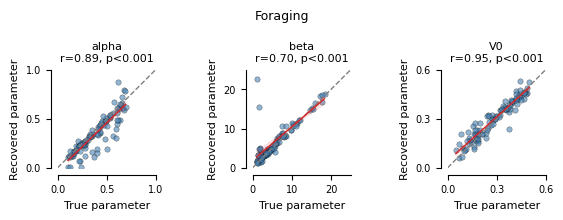

Diagonal rows (parameter recovery): 300


,model_true,model_fitted,iteration,alpha,beta,stickiness_bias,alpha_recovered,beta_recovered,stickiness_bias_recovered,LPT_best,V0,V0_recovered
0,Foraging,Foraging,0,0.429288,6.279654,NaN,0.358653,7.512074,NaN,0.511604,0.321244,0.352760
3,Foraging,Foraging,1,0.350213,6.370626,NaN,0.321578,7.423149,NaN,0.686078,0.050051,0.108900
6,Foraging,Foraging,2,0.361597,3.988790,NaN,0.342569,4.155493,NaN,0.454579,0.245895,0.240599
9,Foraging,Foraging,3,0.430479,6.157539,NaN,0.414226,6.392551,NaN,0.593630,0.180907,0.180958
12,Foraging,Foraging,4,0.680218,3.961880,NaN,0.788190,3.395810,NaN,0.430696,0.487708,0.455558


Detected parameters: ['V0', 'alpha', 'beta', 'stickiness_bias']
Models (diagonal): ['Foraging', 'Inferential RL - stickiness', 'Standard RL - stickiness']
Foraging - alpha: r=0.89, p=1.5546322695324452e-34
Foraging - beta: r=0.70, p=7.333698726172779e-16
Foraging - V0: r=0.95, p=9.299289184573168e-52


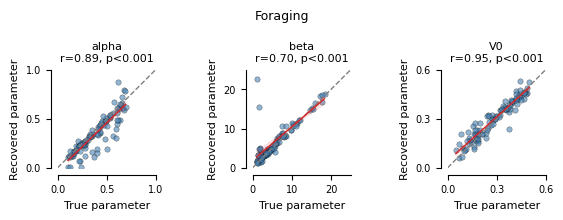

Inferential RL - stickiness - alpha: r=0.76, p=5.3413055467257134e-20
Inferential RL - stickiness - beta: r=0.99, p=6.404205783671646e-94
Inferential RL - stickiness - stickiness_bias: r=0.94, p=3.519149479909797e-47


Diagonal rows (parameter recovery): 300


,model_true,model_fitted,iteration,alpha,beta,stickiness_bias,alpha_recovered,beta_recovered,stickiness_bias_recovered,LPT_best,V0,V0_recovered
0,Foraging,Foraging,0,0.429288,6.279654,NaN,0.358653,7.512074,NaN,0.511604,0.321244,0.352760
3,Foraging,Foraging,1,0.350213,6.370626,NaN,0.321578,7.423149,NaN,0.686078,0.050051,0.108900
6,Foraging,Foraging,2,0.361597,3.988790,NaN,0.342569,4.155493,NaN,0.454579,0.245895,0.240599
9,Foraging,Foraging,3,0.430479,6.157539,NaN,0.414226,6.392551,NaN,0.593630,0.180907,0.180958
12,Foraging,Foraging,4,0.680218,3.961880,NaN,0.788190,3.395810,NaN,0.430696,0.487708,0.455558


Detected parameters: ['V0', 'alpha', 'beta', 'stickiness_bias']
Models (diagonal): ['Foraging', 'Inferential RL - stickiness', 'Standard RL - stickiness']
Foraging - alpha: r=0.89, p=1.5546322695324452e-34
Foraging - beta: r=0.70, p=7.333698726172779e-16
Foraging - V0: r=0.95, p=9.299289184573168e-52


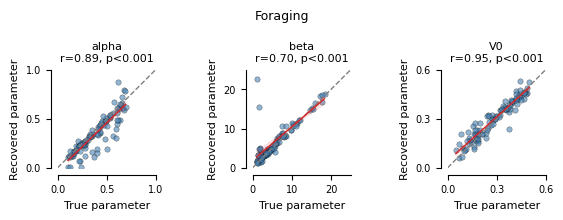

Inferential RL - stickiness - alpha: r=0.76, p=5.3413055467257134e-20
Inferential RL - stickiness - beta: r=0.99, p=6.404205783671646e-94
Inferential RL - stickiness - stickiness_bias: r=0.94, p=3.519149479909797e-47


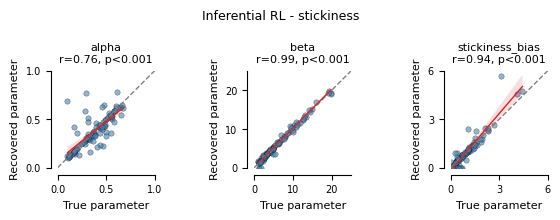

Diagonal rows (parameter recovery): 300


,model_true,model_fitted,iteration,alpha,beta,stickiness_bias,alpha_recovered,beta_recovered,stickiness_bias_recovered,LPT_best,V0,V0_recovered
0,Foraging,Foraging,0,0.429288,6.279654,NaN,0.358653,7.512074,NaN,0.511604,0.321244,0.352760
3,Foraging,Foraging,1,0.350213,6.370626,NaN,0.321578,7.423149,NaN,0.686078,0.050051,0.108900
6,Foraging,Foraging,2,0.361597,3.988790,NaN,0.342569,4.155493,NaN,0.454579,0.245895,0.240599
9,Foraging,Foraging,3,0.430479,6.157539,NaN,0.414226,6.392551,NaN,0.593630,0.180907,0.180958
12,Foraging,Foraging,4,0.680218,3.961880,NaN,0.788190,3.395810,NaN,0.430696,0.487708,0.455558


Detected parameters: ['V0', 'alpha', 'beta', 'stickiness_bias']
Models (diagonal): ['Foraging', 'Inferential RL - stickiness', 'Standard RL - stickiness']
Foraging - alpha: r=0.89, p=1.5546322695324452e-34
Foraging - beta: r=0.70, p=7.333698726172779e-16
Foraging - V0: r=0.95, p=9.299289184573168e-52


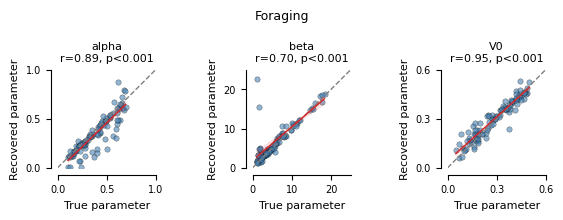

Inferential RL - stickiness - alpha: r=0.76, p=5.3413055467257134e-20
Inferential RL - stickiness - beta: r=0.99, p=6.404205783671646e-94
Inferential RL - stickiness - stickiness_bias: r=0.94, p=3.519149479909797e-47


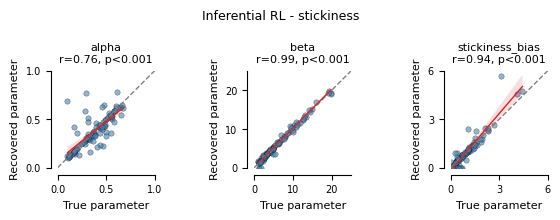

Standard RL - stickiness - alpha: r=0.73, p=1.272986726492464e-17
Standard RL - stickiness - beta: r=0.96, p=1.5436521692895773e-56
Standard RL - stickiness - stickiness_bias: r=0.99, p=3.932453530783439e-90


Diagonal rows (parameter recovery): 300


,model_true,model_fitted,iteration,alpha,beta,stickiness_bias,alpha_recovered,beta_recovered,stickiness_bias_recovered,LPT_best,V0,V0_recovered
0,Foraging,Foraging,0,0.429288,6.279654,NaN,0.358653,7.512074,NaN,0.511604,0.321244,0.352760
3,Foraging,Foraging,1,0.350213,6.370626,NaN,0.321578,7.423149,NaN,0.686078,0.050051,0.108900
6,Foraging,Foraging,2,0.361597,3.988790,NaN,0.342569,4.155493,NaN,0.454579,0.245895,0.240599
9,Foraging,Foraging,3,0.430479,6.157539,NaN,0.414226,6.392551,NaN,0.593630,0.180907,0.180958
12,Foraging,Foraging,4,0.680218,3.961880,NaN,0.788190,3.395810,NaN,0.430696,0.487708,0.455558


Detected parameters: ['V0', 'alpha', 'beta', 'stickiness_bias']
Models (diagonal): ['Foraging', 'Inferential RL - stickiness', 'Standard RL - stickiness']
Foraging - alpha: r=0.89, p=1.5546322695324452e-34
Foraging - beta: r=0.70, p=7.333698726172779e-16
Foraging - V0: r=0.95, p=9.299289184573168e-52


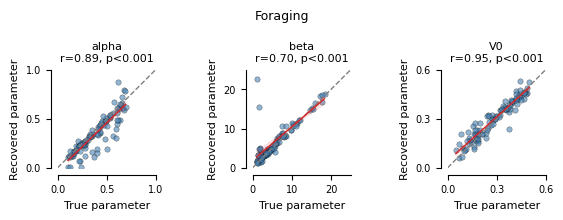

Inferential RL - stickiness - alpha: r=0.76, p=5.3413055467257134e-20
Inferential RL - stickiness - beta: r=0.99, p=6.404205783671646e-94
Inferential RL - stickiness - stickiness_bias: r=0.94, p=3.519149479909797e-47


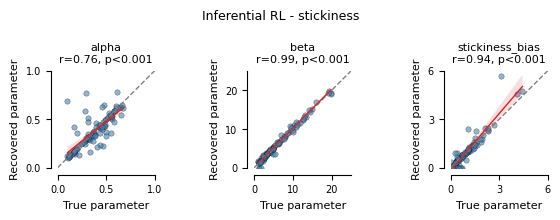

Standard RL - stickiness - alpha: r=0.73, p=1.272986726492464e-17
Standard RL - stickiness - beta: r=0.96, p=1.5436521692895773e-56
Standard RL - stickiness - stickiness_bias: r=0.99, p=3.932453530783439e-90


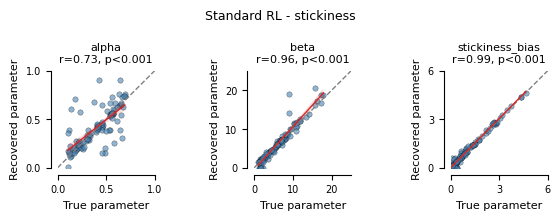

In [20]:

from scipy.stats import pearsonr

plt.rcParams.update({"font.size": 8})

# Diagonal only (same true & fitted model)
df_diag = df[df["model_true"] == df["model_fitted"]].copy()
print(f"Diagonal rows (parameter recovery): {len(df_diag)}")
display(df_diag.head())

# Infer parameter names from *_recovered columns
recovered_cols = [c for c in df_diag.columns if c.endswith("_recovered")]
param_names = [c.replace("_recovered", "") for c in recovered_cols if c.replace("_recovered", "") in df_diag.columns]
param_names = sorted(set(param_names))
print("Detected parameters:", param_names)

models = list(pd.unique(df_diag["model_true"]))
print("Models (diagonal):", models)

# One figure per model, one subplot per parameter
subplot_size = 2  # inches per subplot

ranges = {'alpha': (0, 1), 'beta': (0, 25), 'epsilon': (0, 1), 'stickiness_bias': (0, 6), 'V0': (0, .6)}

# Define nice tick values for each parameter
tick_values = {
    'alpha': [0, 0.5, 1.0],
    'beta': [0, 10, 20],
    'epsilon': [0, 0.5, 1.0],
    'stickiness_bias': [0, 3,  6],
    'V0': [0, 0.3, 0.6]
}

for model_name in models:
    df_m = df_diag[df_diag["model_true"] == model_name]

    # Keep only params that have data for this model
    model_params = []
    for p in param_names:
        if p in df_m.columns and f"{p}_recovered" in df_m.columns:
            if df_m[[p, f"{p}_recovered"]].dropna().shape[0] > 1:
                model_params.append(p)

    # sort alphabetically
    model_params = sorted(model_params, key=lambda x: (x != 'alpha', x != 'beta', x != 'epsilon', x != 'stickiness', x))

    if not model_params:
        continue

    n_params = len(model_params)
    fig, axes = plt.subplots(1, n_params, figsize=(subplot_size * n_params, subplot_size), squeeze=False)
    fig.suptitle(model_name, fontsize=9, y=1.02)

    for col_idx, p in enumerate(model_params):
        ax = axes[0, col_idx]
        sub = df_m[[p, f"{p}_recovered"]].dropna()
        x = sub[p].to_numpy()
        y = sub[f"{p}_recovered"].to_numpy()

        ax.scatter(x, y, alpha=0.6, s=15, edgecolors="black", linewidth=0.3, color="steelblue")

        # Shared axis limits
        '''lo = min(x.min(), y.min())
        hi = max(x.max(), y.max())
        pad = (hi - lo) * 0.05
        lim = (lo - pad, hi + pad)'''
        lim = ranges.get(p, (x.min(), x.max()))
        ax.set_xlim(lim)
        ax.set_ylim(lim)

        # Set matching ticks for both axes
        if p in tick_values:
            ticks = tick_values[p]
            ax.set_xticks(ticks)
            ax.set_yticks(ticks)

        # Identity line
        ax.plot(lim, lim, "grey", linewidth=1.0, linestyle="--", zorder=1)

        # Correlation + p-value
        r, pval = pearsonr(x, y)
        print(f"{model_name} - {p}: r={r:.2f}, p={pval}")
        # plot fit line
        sns.regplot(x=x, y=y, scatter=False, ax=ax, line_kws={"color": "tab:red", "linewidth": 1.0}, label='fit line')
        p_str = f"p<0.001" if pval < 0.001 else f"p={pval:.3f}"
        ax.set_title(f"{p}\nr={r:.2f}, {p_str}", fontsize=8)
        ax.set_xlabel(f"True parameter", fontsize=8)
        ax.set_ylabel(f"Recovered parameter", fontsize=8)
        ax.tick_params(labelsize=7)
        ax.set_aspect("equal", adjustable="box")

        sns.despine(ax=ax)
        ax.spines['left'].set_position(('outward', 5))
        ax.spines['bottom'].set_position(('outward', 5))

    plt.tight_layout()

    # save as svg, transparent background, dpi 300
    plt.savefig(os.path.join(PROJECT_PATH_LOCAL, "notebooks", "behav_modeling", "figs", "recovery", f"model_recovery_{model_name}.svg"), format='svg', dpi=300, bbox_inches='tight')

    plt.show()


## Confusion Matrix (Winner-Takes-All): % iterations each model is best
 
Instead of averaging LPT values, this version asks a simpler question per simulated dataset (iteration):
- For each **true model** and **iteration**, which **fitted model** achieved the highest `LPT_best`?
- The confusion matrix shows the **percentage of iterations** where each fitted model is the winner for that true model (rows sum to 100%).

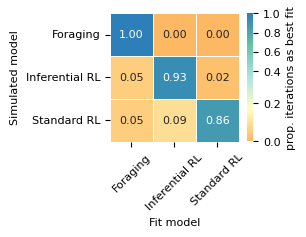

Win counts (rows=true model, cols=winning fitted model):


model_winner,Foraging,Inferential RL - stickiness,Standard RL - stickiness
model_true,,,
Foraging,100,0,0
Inferential RL - stickiness,5,93,2
Standard RL - stickiness,5,9,86


Win proportion (%):


model_winner,Foraging,Inferential RL - stickiness,Standard RL - stickiness
model_true,,,
Foraging,1.00,0.00,0.00
Inferential RL - stickiness,0.05,0.93,0.02
Standard RL - stickiness,0.05,0.09,0.86


In [33]:
# fontsize 8
plt.rcParams.update({"font.size": 8})

# For each (true model, iteration), pick the fitted model with the highest LPT_best
required_cols = {"model_true", "model_fitted", "iteration", "LPT_best"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns in df: {sorted(missing)}")

# idx of the best-fitting model per (true model, iteration)
best_idx = df.groupby(["model_true", "iteration"])["LPT_best"].idxmax()
df_best = df.loc[best_idx, ["model_true", "model_fitted", "iteration", "LPT_best"]].copy()
df_best = df_best.rename(columns={"model_fitted": "model_winner"})

# Row-normalized counts -> percentage of wins
win_counts = pd.crosstab(df_best["model_true"], df_best["model_winner"])
win_pct = win_counts.div(win_counts.sum(axis=1), axis=0)

# Keep a consistent model ordering (if available)
model_order = sorted(pd.unique(df["model_true"]))
win_pct = win_pct.reindex(index=model_order, columns=model_order)

# Strip ' - stickiness' suffix from labels
clean_labels = [l.replace(" - stickiness", "") for l in model_order]

fig, ax = plt.subplots(figsize=(3, 3))

# Use a blue-yellow diverging colormap with enhanced contrast
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap
n_models_heatmap = len(model_order)
chance_level = 1.0 / n_models_heatmap

# Get actual data range to enhance small differences
min_val = win_pct.min().min()
max_val = win_pct.max().max()

# Create custom yellow-white-blue colormap (no red)
colors_map = LinearSegmentedColormap.from_list("yellow_blue", ["#FDB863", "#FFFFBF", "#B2E2E2", "#66C2A4", "#2C7FB8"])

sns.heatmap(
    win_pct,
    annot=True,
    fmt=".2f",
    cmap=colors_map,  # Blue for high (good recovery), yellow for low (confusion)
    norm=TwoSlopeNorm(vmin=min_val, vcenter=chance_level, vmax=max_val),
    cbar_kws={"label": "prop. iterations as best fit", "shrink": 0.6},
    linewidths=0.5,
    linecolor="white",
    ax=ax,
    xticklabels=clean_labels,
    yticklabels=clean_labels,
    square=True,
)
ax.set_xlabel("Fit model")
ax.set_ylabel("Simulated model")
ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()

# save as svg, transparent background, dpi 300
plt.savefig(os.path.join(PROJECT_PATH_LOCAL, "notebooks", "behav_modeling", "figs", "recovery", f"model_recovery_win_pct.svg"), format='svg', dpi=300, bbox_inches='tight')
plt.show()

print("Win counts (rows=true model, cols=winning fitted model):")
display(win_counts.reindex(index=model_order, columns=model_order).fillna(0).astype(int))

print("Win proportion (%):")
display(win_pct)


Binomial test results (H0: recovery rate = chance = 1/n_models):
  Foraging: k=100/100, p=1.940325217482622e-48 *
  Inferential RL: k=93/100, p=4.128492812063062e-36 *
  Standard RL: k=86/100, p=1.5266862314776875e-27 *


/tmp/ipykernel_1301457/3477834031.py:43: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False)


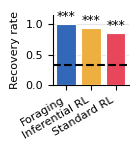

In [6]:

from scipy.stats import binomtest
from popy.config import COLORS

n_models = len(model_order)
chance = 1.0 / n_models

# Recovery rate = diagonal of win_pct
recovery_rates = np.array([win_pct.loc[m, m] if m in win_pct.columns else np.nan for m in model_order])
n_iter = win_counts.sum(axis=1).reindex(model_order).values  # total iterations per true model

# Binomial tests
binom_results = {}
print("Binomial test results (H0: recovery rate = chance = 1/n_models):")
for i, m in enumerate(model_order):
    label = m.replace(" - stickiness", "")
    k = int(win_counts.reindex(index=model_order, columns=model_order).fillna(0).loc[m, m])
    n = int(n_iter[i])
    result = binomtest(k, n, chance, alternative="greater")
    binom_results[m] = result
    print(f"  {label}: k={k}/{n}, p={result.pvalue}{' *' if result.pvalue < 0.05 else ''}")

# Bar plot
clean_labels_diag = [m.replace(" - stickiness", "") for m in model_order]
colors = [COLORS[c] for c in clean_labels_diag]  # Use the same colors as in the heatmap

fig, ax = plt.subplots(figsize=(.5 * n_models, 1.5))
bars = ax.bar(clean_labels_diag, recovery_rates, color=colors, edgecolor="white", linewidth=0.8, zorder=3)

# Chance line
ax.axhline(chance, color="black", linestyle="--", zorder=4)

# Significance stars above bars
for i, (m, bar) in enumerate(zip(model_order, bars)):
    p = binom_results[m].pvalue
    star = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02, star,
            ha="center", va="bottom", fontsize=9)

ax.set_ylim(0, 1.15)
ax.set_ylabel("Recovery rate")
ax.set_xticks(range(n_models))
ax.set_xticklabels(clean_labels_diag, rotation=30, ha="right")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.3, zorder=1)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()
